In [ ]:
"""
Stacking Meta-Classifier with OOF
═══════════════════════════════════════════════

Requires from Drive:
  - oof_resnet50_probs.npy         ← from Notebook 1
  - oof_resnet50_labels.npy        ← from Notebook 1
  - oof_mobilenetv2_probs.npy      ← from Notebook 1
  - oof_mobilenetv2_labels.npy     ← from Notebook 1
  - test_resnet_probs.npy          ← from Notebook 2
  - test_mobilenet_probs.npy       ← from Notebook 2
  - test_labels.npy                ← from Notebook 2

Produces:
  - stacking_report.txt
  - stacking_confusion_matrix.png
  - final_comparison_table.txt     ← all methods compared
"""

# ─────────────────────────────────────────────
# SECTION 1 — Mount & Imports
# ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
drive_dir = "/content/drive/MyDrive"
print(f"Using device: {device}")


Mounted at /content/drive
Using device: cpu


In [ ]:
# ─────────────────────────────────────────────
# SECTION 2 — Load OOF Probabilities (meta-train)
# ─────────────────────────────────────────────
"""
These were saved in Notebook 1 Section 12.

oof_resnet_probs    shape: (6716, 8)
  → probabilities predicted by ResNet50 fold models
    on images they NEVER saw during training
    → realistic, no memorization

oof_mobilenet_probs shape: (6716, 8)
  → same but from MobileNetV2 fold models

oof_labels          shape: (6716,)
  → true class labels for all 6716 train images

These form the meta-classifier training set.
"""
print("Loading OOF arrays (meta-train)...")

oof_resnet_probs    = np.load(f"{drive_dir}/oof_resnet50_probs.npy")
oof_resnet_labels   = np.load(f"{drive_dir}/oof_resnet50_labels.npy")
oof_mobilenet_probs = np.load(f"{drive_dir}/oof_mobilenetv2_probs.npy")
oof_mobilenet_labels= np.load(f"{drive_dir}/oof_mobilenetv2_labels.npy")

# Sanity check — both OOF label arrays must be identical
assert np.array_equal(oof_resnet_labels, oof_mobilenet_labels), \
    "OOF labels from ResNet and MobileNet do not match! " \
    "Check that both were generated with the same random_state=42 split."

oof_labels = oof_resnet_labels   # use either, they are the same
n_train    = len(oof_labels)
print(f"OOF meta-train size : {n_train}")
print(f"OOF resnet  probs   : {oof_resnet_probs.shape}")
print(f"OOF mobilenet probs : {oof_mobilenet_probs.shape}")

# OOF accuracy of each base model
oof_resnet_acc    = accuracy_score(oof_labels,
                                   oof_resnet_probs.argmax(1))
oof_mobilenet_acc = accuracy_score(oof_labels,
                                   oof_mobilenet_probs.argmax(1))
print(f"\nOOF accuracy — ResNet50    : {oof_resnet_acc:.4f}")
print(f"OOF accuracy — MobileNetV2 : {oof_mobilenet_acc:.4f}")

Loading OOF arrays (meta-train)...
OOF meta-train size : 6595
OOF resnet  probs   : (6595, 8)
OOF mobilenet probs : (6595, 8)

OOF accuracy — ResNet50    : 0.9536
OOF accuracy — MobileNetV2 : 0.8922


In [ ]:
# ─────────────────────────────────────────────
# SECTION 3 — Load Test Probabilities (meta-test)
# ─────────────────────────────────────────────
"""
These were saved in Notebook 2 Section 5.
They come from final models trained on the FULL train set,
with TTA applied — strongest possible base predictions.
"""
print("\nLoading test probabilities (meta-test)...")

test_resnet_probs    = np.load(f"{drive_dir}/test_resnet_probs.npy")
test_mobilenet_probs = np.load(f"{drive_dir}/test_mobilenet_probs.npy")
test_labels          = np.load(f"{drive_dir}/test_labels.npy")

n_test       = len(test_labels)
num_classes  = test_resnet_probs.shape[1]
print(f"Test size           : {n_test}")
print(f"Test resnet  probs  : {test_resnet_probs.shape}")
print(f"Test mobilenet probs: {test_mobilenet_probs.shape}")

# Load class names from checkpoint
import torch as _torch
ckpt        = _torch.load(f"{drive_dir}/fine_tuned_resnet50_eca_checkpoint.pth",
                          map_location="cpu", weights_only=False)
idx_to_class = ckpt["idx_to_class"]
class_names  = [idx_to_class[str(i)] if str(i) in idx_to_class
                else idx_to_class[i]
                for i in range(num_classes)]
print(f"Classes ({num_classes}): {class_names}")


Loading test probabilities (meta-test)...
Test size           : 1417
Test resnet  probs  : (1417, 8)
Test mobilenet probs: (1417, 8)
Classes (8): ['Algal leaf spot', 'Brown blight', 'Gray blight', 'Green mirid bug', 'Healthy', 'Helopeltis', 'Red leaf spot', 'Red spider']


In [ ]:
# ─────────────────────────────────────────────
# SECTION 4 — Build Meta Features
# ─────────────────────────────────────────────
"""
Meta features = concatenation of both models' softmax probabilities.

For meta-train (OOF):
  X_meta_train shape: (6716, 16)
  Each row: [resnet_prob_class0..7, mobilenet_prob_class0..7]
  These are REALISTIC probs — generated on unseen fold images

For meta-test:
  X_meta_test  shape: (1437, 16)
  These are the final model probs with TTA on test set

Why 16 features and not more?
  Adding raw logits, confidence scores etc adds noise.
  Clean softmax probs (0→1, sum to 1) are the most
  informative and stable features for the meta-classifier.
"""

X_meta_train = np.concatenate(
    [oof_resnet_probs, oof_mobilenet_probs], axis=1
)   # (6716, 16)

X_meta_test  = np.concatenate(
    [test_resnet_probs, test_mobilenet_probs], axis=1
)   # (1437, 16)

y_meta_train = oof_labels    # (6716,)
y_meta_test  = test_labels   # (1437,)

print(f"\nMeta-train features : {X_meta_train.shape}")
print(f"Meta-test  features : {X_meta_test.shape}")



Meta-train features : (6595, 16)
Meta-test  features : (1417, 16)


In [ ]:
# ─────────────────────────────────────────────
# SECTION 5 — Scale Features
# ─────────────────────────────────────────────
"""
StandardScaler fit on meta-train only.
Same scaler applied to meta-test (transform only, not fit).
This is mandatory — fitting on test would be data leakage.
"""
scaler       = StandardScaler()
X_train_s    = scaler.fit_transform(X_meta_train)
X_test_s     = scaler.transform(X_meta_test)

print("Features scaled (fit on train, transform on test).")


Features scaled (fit on train, transform on test).


In [ ]:
# ─────────────────────────────────────────────
# SECTION 6 — Class Weights for Meta-Classifier
# ─────────────────────────────────────────────
class_counts = {
    "Helopeltis":     917,
    "Algal leaf spot":910,
    "Red spider":     293,
    "Red leaf spot":  700,
    "Healthy":        1238,
    "Gray blight":    1127,
    "Brown blight":   823,
    "Green mirid bug":587
}

# Rebuild class_to_idx from checkpoint
class_to_idx = ckpt["class_to_idx"]
total_s      = sum(class_counts.values())
weights_list = [0.0] * num_classes
for name, idx in class_to_idx.items():
    weights_list[idx] = total_s / (num_classes * class_counts[name])

class_weights_tensor = torch.tensor(
    weights_list, dtype=torch.float
).to(device)

In [ ]:
# ─────────────────────────────────────────────
# SECTION 7 — Meta-Classifier A: Logistic Regression
# ─────────────────────────────────────────────
"""
Why Logistic Regression first?
  - Only 16 input features → LR has enough capacity
  - With 6716 meta-train samples it fits well
  - class_weight='balanced' handles imbalance
  - Interpretable, stable, fast
  - Almost always competitive with neural meta on small feature sets
"""
print("\n" + "="*55)
print("META-CLASSIFIER A — Logistic Regression")
print("="*55)

meta_lr = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs',
    multi_class='multinomial'
)
meta_lr.fit(X_train_s, y_meta_train)

# Evaluate on meta-train (OOF) — shows how well LR fits
lr_train_acc = accuracy_score(y_meta_train,
                              meta_lr.predict(X_train_s))
# Evaluate on test
lr_test_preds = meta_lr.predict(X_test_s)
lr_test_acc   = accuracy_score(y_meta_test, lr_test_preds)

print(f"LR meta-train (OOF) accuracy : {lr_train_acc:.4f}")
print(f"LR test accuracy             : {lr_test_acc:.4f}")

# Also get LR probabilities (useful for blending later)
lr_test_probs = meta_lr.predict_proba(X_test_s)


META-CLASSIFIER A — Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LR meta-train (OOF) accuracy : 0.9557
LR test accuracy             : 0.9598


In [ ]:
# ─────────────────────────────────────────────
# SECTION 8 — Meta-Classifier B: Neural Network
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("META-CLASSIFIER B — Neural Network")
print("="*55)


class MetaNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)


# Convert full meta-train to tensor for test inference
X_tr_t = torch.tensor(X_train_s,    dtype=torch.float32)
y_tr_t = torch.tensor(y_meta_train, dtype=torch.long)
X_ts_t = torch.tensor(X_test_s,     dtype=torch.float32).to(device)

# ── FIX — Shuffle OOF data before splitting ──
# Without shuffling, last 15% = fold 5 only → unbalanced val set
# → val_acc never improves → best_nn_state stays None → crash
shuffle_idx  = np.random.RandomState(42).permutation(len(X_train_s))
X_train_shuf = X_train_s[shuffle_idx]
y_train_shuf = y_meta_train[shuffle_idx]

# Split shuffled data — 85% train, 15% val
split_idx = int(0.85 * len(X_train_shuf))

X_nn_tr  = torch.tensor(X_train_shuf[:split_idx],
                         dtype=torch.float32).to(device)
y_nn_tr  = torch.tensor(y_train_shuf[:split_idx],
                         dtype=torch.long).to(device)
X_nn_val = torch.tensor(X_train_shuf[split_idx:],
                         dtype=torch.float32).to(device)
y_nn_val = y_train_shuf[split_idx:]

nn_train_ds = TensorDataset(X_nn_tr, y_nn_tr)
nn_loader   = DataLoader(nn_train_ds, batch_size=32, shuffle=True)

meta_nn      = MetaNet(X_train_s.shape[1], num_classes).to(device)
criterion_nn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_nn = torch.optim.Adam(meta_nn.parameters(),
                                lr=1e-3, weight_decay=1e-3)

best_nn_acc   = 0.0
best_nn_state = None
patience_nn   = 8
patience_ctr  = 0

for epoch in range(100):
    meta_nn.train()
    for feats, lbls in nn_loader:
        optimizer_nn.zero_grad()
        loss = criterion_nn(meta_nn(feats), lbls)
        loss.backward()
        optimizer_nn.step()

    # Validate
    meta_nn.eval()
    with torch.no_grad():
        val_out  = meta_nn(X_nn_val)
        val_pred = val_out.argmax(1).cpu().numpy()
        val_acc  = accuracy_score(y_nn_val, val_pred)

    if val_acc > best_nn_acc:
        best_nn_acc   = val_acc
        best_nn_state = {k: v.clone()
                         for k, v in meta_nn.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience_nn:
            print(f"  Early stop at epoch {epoch+1}")
            break

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:03d} | "
              f"Internal val acc: {val_acc:.4f} | "
              f"Best: {best_nn_acc:.4f}")

# Safety net — should never trigger after shuffle fix
if best_nn_state is None:
    print("WARNING: model never improved — using current weights")
    best_nn_state = {k: v.clone()
                     for k, v in meta_nn.state_dict().items()}

# Load best weights
meta_nn.load_state_dict(best_nn_state)
meta_nn.eval()

# Test predictions
with torch.no_grad():
    nn_test_out   = meta_nn(X_ts_t)
    nn_test_probs = F.softmax(nn_test_out, dim=1).cpu().numpy()
    nn_test_preds = nn_test_out.argmax(1).cpu().numpy()

nn_test_acc = accuracy_score(y_meta_test, nn_test_preds)
print(f"\nNeural net best internal val acc : {best_nn_acc:.4f}")
print(f"Neural net test accuracy         : {nn_test_acc:.4f}")


META-CLASSIFIER B — Neural Network
  Epoch 010 | Internal val acc: 0.9444 | Best: 0.9455
  Early stop at epoch 13

Neural net best internal val acc : 0.9455
Neural net test accuracy         : 0.9605


In [ ]:
np.save(f"{drive_dir}/lr_test_preds.npy", lr_test_preds)
np.save(f"{drive_dir}/nn_test_preds.npy", nn_test_preds)
print("Stacking predictions saved to Drive.")

Stacking predictions saved to Drive.


In [ ]:
# ─────────────────────────────────────────────
# SECTION 9 — Compare ALL Strategies
# ─────────────────────────────────────────────
"""
Full comparison:
  1. ResNet50 alone
  2. MobileNetV2 alone
  3. Simple average ensemble
  4. Weighted average ensemble (linear OOF weights)
  5. Weighted average ensemble (squared OOF weights)
  6. Stacking — Logistic Regression
  7. Stacking — Neural Network
"""
print("\n" + "="*60)
print("FULL COMPARISON — ALL STRATEGIES")
print("="*60)

# Weighted average predictions (recomputed here for comparison)
total  = oof_resnet_acc + oof_mobilenet_acc
w1     = oof_resnet_acc    / total
w2     = oof_mobilenet_acc / total
w1_sq  = oof_resnet_acc**2    / (oof_resnet_acc**2 + oof_mobilenet_acc**2)
w2_sq  = oof_mobilenet_acc**2 / (oof_resnet_acc**2 + oof_mobilenet_acc**2)

test_r  = torch.tensor(test_resnet_probs)
test_m  = torch.tensor(test_mobilenet_probs)

all_strategies = {
    "ResNet50 only":           test_r.argmax(1).numpy(),
    "MobileNetV2 only":        test_m.argmax(1).numpy(),
    "Simple average":         ((test_r + test_m) / 2).argmax(1).numpy(),
    "Weighted avg (linear)":  (w1 * test_r + w2 * test_m).argmax(1).numpy(),
    "Weighted avg (squared)": (w1_sq * test_r + w2_sq * test_m).argmax(1).numpy(),
    "Stacking — LR":           lr_test_preds,
    "Stacking — Neural Net":   nn_test_preds,
}

print(f"\n{'Strategy':<30} {'Accuracy':>10} {'Precision':>10} "
      f"{'Recall':>10} {'F1':>10}")
print("─" * 72)

results_summary = {}
best_acc, best_name, best_preds = 0.0, "", None

for name, preds in all_strategies.items():
    acc  = accuracy_score(y_meta_test,  preds)
    prec = precision_score(y_meta_test, preds, average='weighted',
                           zero_division=0)
    rec  = recall_score(y_meta_test,    preds, average='weighted',
                        zero_division=0)
    f1   = f1_score(y_meta_test,        preds, average='weighted',
                    zero_division=0)
    print(f"{name:<30} {acc:>10.4f} {prec:>10.4f} "
          f"{rec:>10.4f} {f1:>10.4f}")

    results_summary[name] = {
        "accuracy": acc, "precision": prec,
        "recall": rec, "f1": f1
    }
    if acc > best_acc:
        best_acc   = acc
        best_name  = name
        best_preds = preds

print("─" * 72)
print(f"Best overall: {best_name}  (accuracy={best_acc:.4f})")


FULL COMPARISON — ALL STRATEGIES

Strategy                         Accuracy  Precision     Recall         F1
────────────────────────────────────────────────────────────────────────
ResNet50 only                      0.9548     0.9559     0.9548     0.9550
MobileNetV2 only                   0.9083     0.9160     0.9083     0.9089
Simple average                     0.9591     0.9601     0.9591     0.9592
Weighted avg (linear)              0.9591     0.9601     0.9591     0.9592
Weighted avg (squared)             0.9584     0.9594     0.9584     0.9585
Stacking — LR                      0.9598     0.9608     0.9598     0.9599
Stacking — Neural Net              0.9612     0.9626     0.9612     0.9614
────────────────────────────────────────────────────────────────────────
Best overall: Stacking — Neural Net  (accuracy=0.9612)


In [ ]:
# ─────────────────────────────────────────────
# SECTION 10 — Full Evaluation on Best Strategy
# ─────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"FULL EVALUATION — {best_name}")
print(f"{'='*55}")
print(f"Accuracy  : {accuracy_score(y_meta_test, best_preds):.4f}")
print(f"Precision : {precision_score(y_meta_test, best_preds, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_meta_test, best_preds, average='weighted'):.4f}")
print(f"F1 Score  : {f1_score(y_meta_test, best_preds, average='weighted'):.4f}")

report = classification_report(y_meta_test, best_preds,
                               target_names=class_names)
print("\nClassification Report:\n", report)


FULL EVALUATION — Stacking — Neural Net
Accuracy  : 0.9612
Precision : 0.9626
Recall    : 0.9612
F1 Score  : 0.9614

Classification Report:
                  precision    recall  f1-score   support

Algal leaf spot       0.97      0.96      0.97       196
   Brown blight       0.93      0.93      0.93       177
    Gray blight       0.97      0.93      0.95       242
Green mirid bug       0.86      0.97      0.91       126
        Healthy       0.99      1.00      0.99       266
     Helopeltis       0.98      0.95      0.97       197
  Red leaf spot       1.00      0.99      0.99       150
     Red spider       0.94      0.98      0.96        63

       accuracy                           0.96      1417
      macro avg       0.96      0.96      0.96      1417
   weighted avg       0.96      0.96      0.96      1417



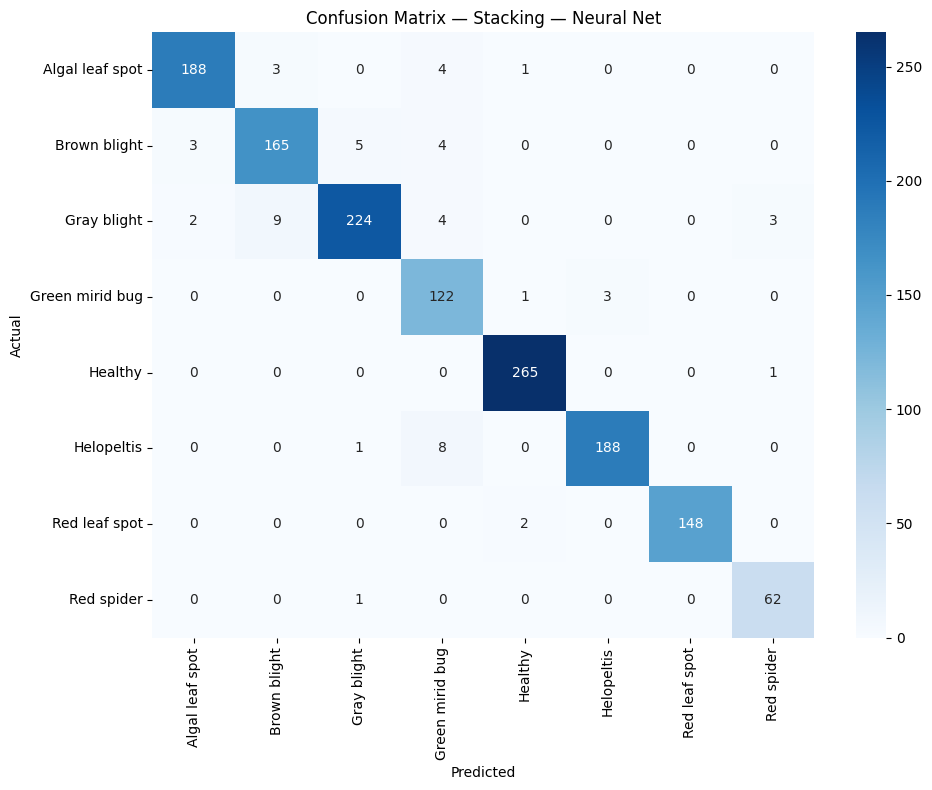

In [ ]:
# ─────────────────────────────────────────────
# SECTION 11 — Confusion Matrix (Best Strategy)
# ─────────────────────────────────────────────
cm = confusion_matrix(y_meta_test, best_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig(f"{drive_dir}/stacking_confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
# ─────────────────────────────────────────────
# SECTION 12 — Per-Class Accuracy Breakdown
# ─────────────────────────────────────────────
"""
Shows which model handles which disease best.
Useful for your research paper results section.
"""
print(f"\n{'─'*75}")
print(f"{'Class':<22} {'ResNet':>8} {'Mobile':>8} "
      f"{'Ensemble':>10} {'Stk-LR':>8} {'Stk-NN':>8} {'Best':>12}")
print(f"{'─'*75}")

resnet_preds   = test_r.argmax(1).numpy()
mobile_preds   = test_m.argmax(1).numpy()
wavg_preds     = (w1 * test_r + w2 * test_m).argmax(1).numpy()

for i, cls in enumerate(class_names):
    mask   = y_meta_test == i
    acc_r  = (resnet_preds[mask]  == y_meta_test[mask]).mean()
    acc_m  = (mobile_preds[mask]  == y_meta_test[mask]).mean()
    acc_e  = (wavg_preds[mask]    == y_meta_test[mask]).mean()
    acc_lr = (lr_test_preds[mask] == y_meta_test[mask]).mean()
    acc_nn = (nn_test_preds[mask] == y_meta_test[mask]).mean()

    best_cls = max(
        [("ResNet",    acc_r),
         ("Mobile",    acc_m),
         ("Ensemble",  acc_e),
         ("Stk-LR",    acc_lr),
         ("Stk-NN",    acc_nn)],
        key=lambda x: x[1]
    )[0]

    print(f"{cls:<22} {acc_r:>8.3f} {acc_m:>8.3f} "
          f"{acc_e:>10.3f} {acc_lr:>8.3f} {acc_nn:>8.3f} "
          f"{best_cls:>12}")


───────────────────────────────────────────────────────────────────────────
Class                    ResNet   Mobile   Ensemble   Stk-LR   Stk-NN         Best
───────────────────────────────────────────────────────────────────────────
Algal leaf spot           0.954    0.944      0.964    0.954    0.959     Ensemble
Brown blight              0.910    0.910      0.921    0.921    0.932       Stk-NN
Gray blight               0.934    0.777      0.921    0.930    0.926       ResNet
Green mirid bug           0.937    0.913      0.960    0.960    0.968       Stk-NN
Healthy                   1.000    0.977      1.000    0.996    0.996       ResNet
Helopeltis                0.954    0.883      0.959    0.959    0.954     Ensemble
Red leaf spot             0.987    0.953      0.973    0.987    0.987       ResNet
Red spider                0.937    0.968      0.984    0.984    0.984     Ensemble


In [ ]:
# ─────────────────────────────────────────────
# SECTION 13 — Save All Results to Drive
# ─────────────────────────────────────────────
# Full stacking report
with open(f"{drive_dir}/stacking_report.txt", "w") as f:
    f.write(f"Best Strategy: {best_name}\n\n")
    f.write(report)
print(f"\nStacking report saved.")

# Final comparison table
with open(f"{drive_dir}/final_comparison_table.txt", "w") as f:
    f.write(f"{'Strategy':<30} {'Accuracy':>10} {'Precision':>10} "
            f"{'Recall':>10} {'F1':>10}\n")
    f.write("─" * 72 + "\n")
    for name, metrics in results_summary.items():
        f.write(
            f"{name:<30} "
            f"{metrics['accuracy']:>10.4f} "
            f"{metrics['precision']:>10.4f} "
            f"{metrics['recall']:>10.4f} "
            f"{metrics['f1']:>10.4f}\n"
        )
    f.write("─" * 72 + "\n")
    f.write(f"Best: {best_name} (accuracy={best_acc:.4f})\n")

print(f"Final comparison table saved.")
print(f"\nAll outputs saved to {drive_dir}")
print(f"\nDone. Best strategy: {best_name} | Accuracy: {best_acc:.4f}")


Stacking report saved.
Final comparison table saved.

All outputs saved to /content/drive/MyDrive

Done. Best strategy: Stacking — Neural Net | Accuracy: 0.9612
